# Simulating a 3D balanced SSFP acquisition

[`01_build.ipynb`](01_build.ipynb) writes two protocols -- a representative `192 x 192 x 16`
acquisition and a reduced one at the **same TR** -- each as a continuous and an interrupted
segmented file. It asserts that they are balanced, which is a statement about gradient waveforms.

**It is not a statement that the acquisition produces the image it is supposed to.** This notebook
answers the questions a waveform check cannot:

```text
1. what preparation should this protocol use, and why not the other one?
2. what did 01 actually write?
3. does the continuous acquisition reconstruct into the right volume?
4. what does interrupted segmentation change?
5. does it behave like bSSFP at all?
6. what remains a protocol choice?
```

Everything simulated here is a file `01` wrote. The reduced protocol is the one that is affordable
to simulate; it shares the representative protocol's preparation, phase cycle, view order,
segmentation rule and TR, and `01` writes it from the same functions so the relationship is
inspectable rather than asserted.

In [1]:
import os
import sys

#: MRzero's inner loop takes every core it is offered.  Hold it to four, before torch is imported.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import contextlib
import os as _os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
plt.rcParams['figure.dpi'] = 72
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402 -- the shared BrainWeb preparation, one directory up

SEQ_DIR = Path('seq')
#: Diagnostics are not acquisitions: single locations read hundreds of times.  Their own directory,
#: so `seq/` holds only the four files 01 ships.
DIAG_DIR = SEQ_DIR / 'diagnostics'
DIAG_DIR.mkdir(parents=True, exist_ok=True)

#: The two brain volumes are the expensive part.  Every *number* below is measured on a single
#: voxel and runs either way.
BRAIN_IMAGES = True

nominal = np.load(SEQ_DIR / 'bssfp_3d_nominal.npz')
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
SLAB_MM, FLIP_DEG = float(nominal['slab_mm']), float(nominal['flip_deg'])
BANDWIDTH_HZ_PX = float(nominal['bandwidth_hz_px'])
RF_DURATION_S = float(nominal['rf_duration_s'])
PHASE_STEP, RAMP_STEPS = float(nominal['phase_step']), int(nominal['ramp_steps'])
SEGMENTS, RECOVERY_S = int(nominal['segments']), float(nominal['recovery_s'])

#: The reduced protocol is what gets simulated; the representative one is read back in section 2.
NX, NY, NZ = (int(v) for v in nominal['validation_matrix'])
TE_S, TR_S = float(nominal['validation_te_s']), float(nominal['validation_tr_s'])
TABLE = [tuple(int(v) for v in row) for row in nominal['validation_table']]
CENTER_LINE = int(nominal['validation_center_line'])
CENTER_PARTITION = int(nominal['validation_center_partition'])

print(f'representative  {tuple(int(v) for v in nominal["matrix"])}  '
      f'TE {float(nominal["te_s"]) * 1e3:.3f}  TR {float(nominal["tr_s"]) * 1e3:.3f} ms')
print(f'validation      {(NX, NY, NZ)}  TE {TE_S * 1e3:.3f}  TR {TR_S * 1e3:.3f} ms  '
      f'-- same TR: {abs(TR_S - float(nominal["tr_s"])) < 1e-12}')
print(f'preparation     {str(nominal["preparation"])}, {RAMP_STEPS} steps')
print(f'view order      {str(nominal["view_order"])}, {SEGMENTS} segments, '
      f'{RECOVERY_S * 1e3:.0f} ms recovery')
print(f'budget          {torch.get_num_threads()} torch threads, '
      f'brain images {"on" if BRAIN_IMAGES else "off"}')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


representative  (192, 192, 16)  TE 2.104  TR 4.210 ms
validation      (48, 32, 8)  TE 2.100  TR 4.210 ms  -- same TR: True
preparation     linear flip-angle ramp, 24 steps
view order      loop order, bidirectional ky, 4 segments, 1000 ms recovery
budget          4 torch threads, brain images on


In [2]:
opts = pp.Opts(
    max_grad=32, grad_unit='mT/m', max_slew=130, slew_unit='T/m/s', B0=3.0,
    rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
)


def kernel_at(flip_deg, tr_s=None):
    '''A repetition of the reduced protocol at `flip_deg`, pinned to the shared TR.'''
    return sc.modules.bSSFP3DTR(
        opts=opts, fov_mm=FOV_MM, matrix=(NX, NY, NZ), slab_thickness_mm=SLAB_MM,
        flip_deg=flip_deg, bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S,
        tr_s=TR_S if tr_s is None else tr_s,
    )


kernel = kernel_at(FLIP_DEG)
assert abs(kernel.tr_s - TR_S) < 1e-12 and abs(kernel.te_s - TE_S) < 1e-12
ECHO, SAMPLES = kernel.ro.echo_sample(0), int(kernel.ro.adc.num_samples)
NAV = pp.make_label(type='SET', label='NAV', value=1)


@contextlib.contextmanager
def quiet():
    '''Silence the solver's log: it is written to file descriptor 1 from Rust.'''
    saved, null = _os.dup(1), _os.open(_os.devnull, _os.O_WRONLY)
    try:
        _os.dup2(null, 1)
        yield
    finally:
        _os.dup2(saved, 1)
        _os.close(null)
        _os.close(saved)


def simulate(path, obj, *, states=200):
    seq = mr0.Sequence.import_file(str(path))
    with quiet():
        graph = mr0.compute_graph(seq, obj, max_state_count=states, min_state_mag=1e-4)
        signal = mr0.execute_graph(graph, seq, obj, min_emitted_signal=1e-4,
                                   min_latent_signal=1e-5, print_progress=False)
    return np.asarray(signal.detach().cpu().numpy()).reshape(-1, SAMPLES)


def voxel(T1, T2, B0=0.0, size_m=0.001):
    '''One small box.  Small matters in section 4, where its own k-space must be flat.'''
    return mr0.CustomVoxelPhantom(pos=[[0.0, 0.0, 0.0]], PD=1.0, T1=T1, T2=T2, T2dash=1e3,
                                  D=0.0, B0=B0, voxel_size=size_m, voxel_shape='box').build()


TISSUES = {'white matter': dict(T1=0.83, T2=0.080),
           'grey matter':  dict(T1=1.33, T2=0.110),
           'CSF':          dict(T1=4.00, T2=2.000)}
NULL_HZ = 1.0 / (2 * TR_S)
print(f'echo sample {ECHO} of {SAMPLES}; band edge (null) at {NULL_HZ:.0f} Hz')

echo sample 24 of 48; band edge (null) at 119 Hz


## 1. What preparation should this protocol use?

### First: what a preparation can and cannot do

Hargreaves et al. (2001) write one repetition as a discrete-time system, `M(k+1) = A M(k) + B`.
Subtracting the fixed point gives `Q(k+1) = A Q(k)` for the error `Q = M - M_ss`, so the approach to
steady state is the zero-input response of a third-order linear system and **decays at the
eigenvalues of `A`**.

That matters for what follows: `A` is built from T1, T2, TR, the flip angle and off-resonance. A
preparation pulse changes the *initial* error `Q(0)`. It does not touch `A`, so it cannot change
the rate. What it can do -- and the reason catalyzation is worth doing -- is start the train with a
smaller error, so the signal falls inside a useful tolerance earlier.

`A` is cheap to write down, so the rate can be computed rather than inferred from a finite
simulation.

In [3]:
def rot_x(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def rot_z(p):
    c, s = np.cos(p), np.sin(p)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def transfer(T1, T2, df_hz=0.0, flip_deg=FLIP_DEG, tr_s=TR_S, phase_step=PHASE_STEP):
    '''Hargreaves Eq. [1]: precession and relaxation over TR, then the RF rotation.

    The 0/pi RF alternation is folded into the precession as an extra pi per TR, which is the
    same equivalence the Handbook states for sign-alternated bSSFP.
    '''
    E1, E2 = np.exp(-tr_s / T1), np.exp(-tr_s / T2)
    theta = 2 * np.pi * df_hz * tr_s + np.deg2rad(phase_step)
    R = rot_x(np.deg2rad(flip_deg))
    return R @ np.diag([E2, E2, E1]) @ rot_z(theta), R @ np.array([0, 0, 1 - E1])


print(f'{"tissue":14s}{"|lambda| max":>14s}{"reps / e":>10s}{"seconds / e":>13s}'
      f'{"reps to 5%":>12s}{"to 1%":>8s}')
DECAY = {}
for name, t in TISSUES.items():
    A, _ = transfer(**t)
    lam = np.abs(np.linalg.eigvals(A)).max()
    DECAY[name] = lam
    tau = -1 / np.log(lam)
    print(f'{name:14s}{lam:14.5f}{tau:10.1f}{tau * TR_S:13.3f}'
          f'{np.log(0.05) / np.log(lam):12.0f}{np.log(0.01) / np.log(lam):8.0f}')
print()
print('These are properties of the repetition, not of any preparation.  They also set how long a')
print('train has to run before its tail can honestly be called a steady state.')

tissue          |lambda| max  reps / e  seconds / e  reps to 5%   to 1%
white matter         0.98804      83.1        0.350         249     383
grey matter          0.99173     120.4        0.507         361     554
CSF                  0.99879     828.8        3.489        2483    3817

These are properties of the repetition, not of any preparation.  They also set how long a
train has to run before its tail can honestly be called a steady state.


### Then: which preparation, measured where it matters

The two named schemes are `alpha/2 - TR/2` and a linear flip-angle ramp. Comparing them **only on
resonance** would not settle anything: bSSFP is run with a passband of finite width, tissue spans
it, and the `alpha/2` pulse is non-selective -- Hargreaves' analysis is that such a pulse rotates
magnetisation toward the steady state for part of the frequency range and away from it for the
rest. So the comparison below sweeps off-resonance from the passband centre toward the band edge.

`REPS` is set from the table above: white matter reaches 1% of its steady state in about 380
repetitions, so a 450-repetition train has a tail that can be used as a reference.

In [4]:
REPS = 450


def half_angle_block(flip_deg):
    exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg / 2, thickness_mm=SLAB_MM,
                                duration_s=0.5e-3)
    a_post = -exc.rephaser_area_per_m
    a_pre = float(exc.gz.area) - a_post
    lead = pp.make_trapezoid(channel='z', area=-a_pre, system=opts)
    lead_s = float(pp.calc_duration(lead))
    out = sc.LogicBlock('alpha_over_2')
    out.add(0.0, lead)
    out.add(lead_s, exc(rephase=True))
    return out, lead_s + exc.time_to_center()


def transient_file(path, prep, *, reps=REPS, b1=1.0):
    '''`reps` repetitions at the centre of k-space after `prep`; returns the first imaging index.'''
    k = kernel_at(FLIP_DEG * b1)
    out, at, n, first = sc.LogicBlock('transient'), 0.0, 0, 0
    if prep == 'alpha/2':
        block, to_centre = half_angle_block(FLIP_DEG * b1)
        out.add(0.0, block)
        at = sc.Raster(opts.grad_raster_time).ceil(to_centre + TR_S / 2 - k.time_to_rf_center())
        n = 1                       # the alpha/2 pulse takes the first slot in the alternation
    elif isinstance(prep, int):
        for j in range(prep):
            r = kernel_at(FLIP_DEG * b1 * (j + 1) / (prep + 1))
            out.add(at, r(line=CENTER_LINE, partition=CENTER_PARTITION, phase_deg=PHASE_STEP * n))
            out.add(at, NAV)
            at, n, first = at + r.tr_s, n + 1, first + 1
    for _ in range(reps):
        out.add(at, k(line=CENTER_LINE, partition=CENTER_PARTITION, phase_deg=PHASE_STEP * n))
        out.add(at, NAV)
        at, n = at + TR_S, n + 1
    sc.compile(out, opts, name=path.stem).write(str(path))
    return first, k


def peak_transient(path, first, k, df=0.0, tissue='white matter', window=60):
    '''Largest |deviation| in the first `window` imaging repetitions, over the late-train level.'''
    rows = simulate(path, voxel(B0=df, **TISSUES[tissue]))
    s = np.abs(rows[first:, k.ro.echo_sample(0)])
    late = s[-40:].mean()
    return np.abs(s[:window] - late).max() / late, s / late


CANDIDATES = {'none': ('none', 'prep_none'),
              'alpha/2 - TR/2': ('alpha/2', 'prep_alpha_over_2'),
              f'{RAMP_STEPS}-step ramp': (RAMP_STEPS, f'prep_ramp{RAMP_STEPS}')}
BUILT = {name: transient_file(DIAG_DIR / f'{stem}.seq', prep)
         for name, (prep, stem) in CANDIDATES.items()}

offsets = [0.0, 0.5 * NULL_HZ, 0.75 * NULL_HZ, 0.9 * NULL_HZ]
print('peak transient over the first 60 imaging repetitions, / late-train signal (white matter)')
print(f'{"preparation":18s}' + ''.join(f'{f"{o:.0f} Hz":>11s}' for o in offsets))
CURVES = {}
for name, (prep, stem) in CANDIDATES.items():
    first, k = BUILT[name]
    cells = []
    for o in offsets:
        peak, curve = peak_transient(DIAG_DIR / f'{stem}.seq', first, k, df=o)
        cells.append(f'{peak:11.2f}')
        if o == 0.0:
            CURVES[name] = curve
    print(f'{name:18s}' + ''.join(cells))

peak transient over the first 60 imaging repetitions, / late-train signal (white matter)
preparation              0 Hz      59 Hz      89 Hz     107 Hz


none                     3.59       5.31      10.41      25.24


alpha/2 - TR/2           1.53       3.59       9.55      24.71


24-step ramp             1.45       2.55       5.82      10.80


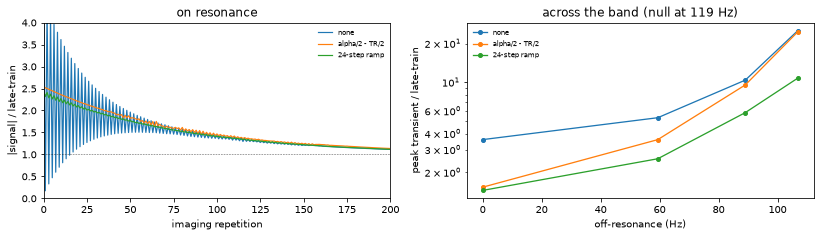

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
for name, curve in CURVES.items():
    axes[0].plot(curve, lw=1.2, label=name)
axes[0].axhline(1.0, color='k', lw=0.6, ls=':')
axes[0].set(xlabel='imaging repetition', ylabel='|signal| / late-train',
            title='on resonance', xlim=(0, 200), ylim=(0, 4))
axes[0].legend(fontsize=7, frameon=False)

for name, (prep, stem) in CANDIDATES.items():
    first, k = BUILT[name]
    sweep = [peak_transient(DIAG_DIR / f'{stem}.seq', first, k, df=o)[0]
             for o in offsets]
    axes[1].plot(offsets, sweep, 'o-', lw=1.3, ms=4, label=name)
axes[1].set(xlabel='off-resonance (Hz)', ylabel='peak transient / late-train',
            title=f'across the band (null at {NULL_HZ:.0f} Hz)', yscale='log')
axes[1].legend(fontsize=7, frameon=False)
fig.tight_layout()

In [6]:
print('B1 robustness at the passband centre, same metric:')
print(f'{"preparation":18s}' + ''.join(f'{f"B1 x{b:.2f}":>11s}' for b in (0.9, 1.0, 1.1)))
for name, (prep, stem) in CANDIDATES.items():
    cells = []
    for b1 in (0.9, 1.0, 1.1):
        path = DIAG_DIR / f'{stem}_b1{int(b1 * 100)}.seq'
        first, k = transient_file(path, prep, b1=b1)
        cells.append(f'{peak_transient(path, first, k)[0]:11.2f}')
    print(f'{name:18s}' + ''.join(cells))

B1 robustness at the passband centre, same metric:
preparation          B1 x0.90   B1 x1.00   B1 x1.10


none                     3.10       3.59       4.16


alpha/2 - TR/2           1.23       1.53       1.89


24-step ramp             1.17       1.45       1.77


### What that settles

**On resonance the two schemes are equivalent, and across the band they are not.** The `alpha/2`
pulse holds its advantage near the passband centre and loses it toward the edge; the ramp degrades
more slowly. That is the behaviour Hargreaves predicts for a non-selective half-angle pulse, and it
is the reason `01` ships the ramp.

**B1 does not separate them.** Both stay close to their nominal behaviour over `+-10%`, because in
both schemes every preparation pulse scales with the same B1 as the imaging pulses.

What neither of them does is change the decay rate. The curves on the left all approach the same
asymptote on the same timescale -- the eigenvalue from the previous section -- they simply start
closer to or further from it.

**CSF is excluded from any "repetitions to settle" claim here.** Its eigenvalue implies about 2500
repetitions to reach 5%, which is far beyond this train, so the tail of a 450-repetition CSF
simulation is not a steady state and must not be used as one.

## 2. What did `01` actually write?

`01` already asserts the artifact contract as it writes the files, and that check runs in
continuous integration. What is useful here is the acquisition *structure*: which views each file
visits, in what order, and where the centre of k-space falls relative to each ramp.

In [7]:
for stem in ('bssfp_3d', 'bssfp_3d_segmented',
             'bssfp_3d_validation', 'bssfp_3d_validation_segmented'):
    seq = pp.Sequence()
    seq.read(str(SEQ_DIR / f'{stem}.seq'))
    adcs = sum(1 for i in range(1, len(seq.block_events) + 1)
               if getattr(seq.get_block(i), 'adc', None) is not None)
    print(f'{stem:34s} {adcs:5d} readouts  {seq.duration()[0]:7.2f} s  '
          f'TR {float(seq.definitions["TR"]) * 1e3:.3f} ms')
print()
print(f'simulating the two validation files; the representative pair is the same policy at '
      f'{tuple(int(v) for v in nominal["matrix"])}')

bssfp_3d                            3072 readouts    13.03 s  TR 4.210 ms


bssfp_3d_segmented                  3072 readouts    16.34 s  TR 4.210 ms
bssfp_3d_validation                  256 readouts     1.18 s  TR 4.210 ms
bssfp_3d_validation_segmented        256 readouts     4.48 s  TR 4.210 ms

simulating the two validation files; the representative pair is the same policy at (192, 192, 16)


largest |ky| step between consecutive views: 1
centre of k-space is view 144 of 256, 16 views into segment 2, which is 67 ms after that segment's ramp


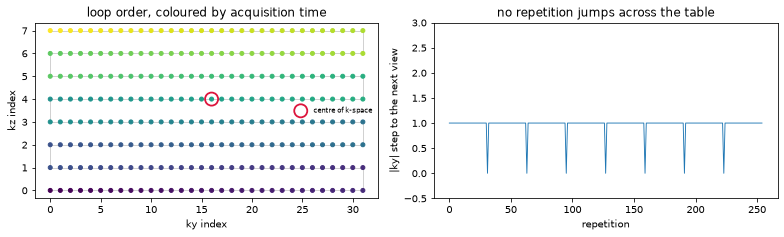

In [8]:
order = np.array(TABLE)
per_segment = len(TABLE) // SEGMENTS
centre_at = TABLE.index((CENTER_LINE, CENTER_PARTITION))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.4))
axes[0].plot(order[:, 0], order[:, 1], lw=0.6, color='0.7', zorder=1)
axes[0].scatter(order[:, 0], order[:, 1], c=np.arange(len(order)), cmap='viridis', s=16, zorder=2)
axes[0].scatter([CENTER_LINE], [CENTER_PARTITION], facecolors='none', edgecolors='crimson',
                s=170, lw=1.8, label='centre of k-space')
axes[0].set(xlabel='ky index', ylabel='kz index',
            title='loop order, coloured by acquisition time')
axes[0].legend(fontsize=7, frameon=False)

steps = np.abs(np.diff(order[:, 0]))
axes[1].plot(steps, lw=0.9)
axes[1].set(xlabel='repetition', ylabel='|ky| step to the next view',
            title='no repetition jumps across the table', ylim=(-0.5, max(3, steps.max() + 0.5)))
fig.tight_layout()

print(f'largest |ky| step between consecutive views: {steps.max()}')
print(f'centre of k-space is view {centre_at} of {len(TABLE)}, '
      f'{centre_at % per_segment} views into segment {centre_at // per_segment}, '
      f'which is {(centre_at % per_segment) * TR_S * 1e3:.0f} ms after that segment\'s ramp')

## 3. Does the continuous acquisition reconstruct correctly?

A 3D FFT of the sorted table. The three matrix dimensions are all different, so a `ky`/`kz` swap or
a transposed reconstruction changes the **shape** of the volume rather than producing a plausible
image.

volume (48, 32, 8), peak at (np.int64(34), np.int64(18), np.int64(4))


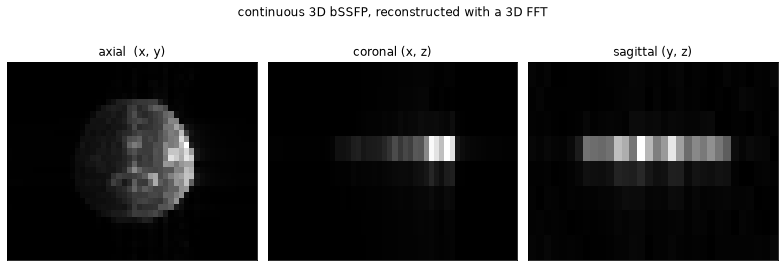

In [9]:
def reconstruct(rows):
    '''Sort repetitions into (kx, ky, kz) and take the 3D FFT.

    The table's indices are zero-based with DC at `matrix // 2`, which is the order `ifftshift`
    expects -- the centre convention the modules use is the one this assumes.
    '''
    cube = np.zeros((NX, NY, NZ), dtype=complex)
    for row, (line, partition) in enumerate(TABLE):
        cube[:, line, partition] = rows[row]
    return cube, np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(cube)))


def three_planes(volume, title):
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
    for ax, (name, plane) in zip(axes, (
            ('axial  (x, y)', volume[:, :, NZ // 2].T),
            ('coronal (x, z)', volume[:, NY // 2, :].T),
            ('sagittal (y, z)', volume[NX // 2, :, :].T))):
        ax.imshow(plane, cmap='gray', origin='lower', aspect='auto')
        ax.set(title=name, xticks=[], yticks=[])
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


if BRAIN_IMAGES:
    brain = ph.built(matrix=NX, nz=NZ, n_coils=1)
    rows_cont = simulate(SEQ_DIR / 'bssfp_3d_validation.seq', brain)
    k_cont, vol_cont = reconstruct(rows_cont)
    three_planes(np.abs(vol_cont), 'continuous 3D bSSFP, reconstructed with a 3D FFT')
    print(f'volume {vol_cont.shape}, peak at '
          f'{np.unravel_index(np.argmax(np.abs(vol_cont)), vol_cont.shape)}')
else:
    print('BRAIN_IMAGES is off -- skipping the two volume simulations')

The volume is `(48, 32, 8)`: readout, phase encode, partition. The sagittal plane is `32 x 8` and
visibly coarse along `z`, which is the geometry this reduced protocol asked for rather than an
artifact -- the representative protocol encodes the same slab with 16 partitions over a finer
in-plane matrix.

## 4. What does interrupted segmentation change?

Both files cover the same table in the same order. The only difference is that the segmented one is
cut into four ramped blocks with a one-second recovery between them -- which is what an acquisition
does when it has to fit inside a breath-hold or a cardiac window. So every difference below comes
from magnetisation history, not from encoding.

It is measured on a **point object**, because a small enough object has essentially flat k-space
across the table, and then whatever structure appears in its *measured* k-space is the
acquisition's own modulation with no anatomy to hide behind. "Small enough" is a real condition: a
box of side `d` has its first k-space null at `1/d`, this table reaches `|ky| = NY/2 / FOV_y`, and
the 1 mm box used here nulls far outside it.

|ky| extent 53 1/m; a 1 mm box first nulls at 1000 1/m

mean |signal| per partition, in acquisition order:
  continuous    1.73   1.44   1.23   1.09   1.00   0.93   0.89   0.86
  segmented     1.73   1.44   1.57   1.32   1.55   1.31   1.54   1.31


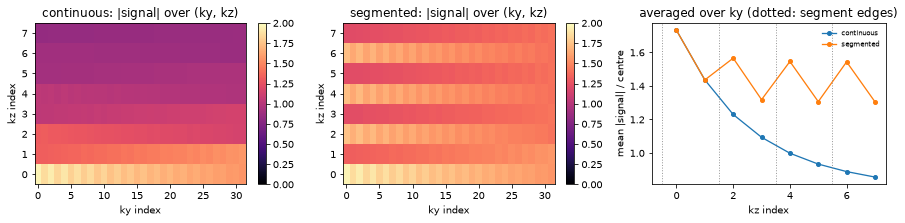

In [10]:
point = voxel(size_m=0.001, **TISSUES['white matter'])
k_cont_pt, _ = reconstruct(simulate(SEQ_DIR / 'bssfp_3d_validation.seq', point))
k_seg_pt, _ = reconstruct(simulate(SEQ_DIR / 'bssfp_3d_validation_segmented.seq', point))

mod_cont, mod_seg = np.abs(k_cont_pt[ECHO]), np.abs(k_seg_pt[ECHO])
flat = mod_cont[CENTER_LINE, CENTER_PARTITION]
kmax_y = (NY // 2) / (FOV_MM[1] * 1e-3)
print(f'|ky| extent {kmax_y:.0f} 1/m; a 1 mm box first nulls at {1 / 0.001:.0f} 1/m')
print()

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.2))
for ax, (name, m) in zip(axes, (('continuous', mod_cont), ('segmented', mod_seg))):
    im = ax.imshow(m.T / flat, origin='lower', aspect='auto', cmap='magma', vmin=0, vmax=2.0)
    ax.set(title=f'{name}: |signal| over (ky, kz)', xlabel='ky index', ylabel='kz index')
    fig.colorbar(im, ax=ax, fraction=0.046)
axes[2].plot(mod_cont.mean(axis=0) / flat, 'o-', lw=1.3, ms=4, label='continuous')
axes[2].plot(mod_seg.mean(axis=0) / flat, 'o-', lw=1.3, ms=4, label='segmented')
for b in range(SEGMENTS):
    axes[2].axvline(b * NZ / SEGMENTS - 0.5, color='0.6', ls=':', lw=1.0)
axes[2].set(xlabel='kz index', ylabel='mean |signal| / centre',
            title='averaged over ky (dotted: segment edges)')
axes[2].legend(fontsize=7, frameon=False)
fig.tight_layout()

print('mean |signal| per partition, in acquisition order:')
for name, m in (('continuous', mod_cont), ('segmented', mod_seg)):
    print(f'  {name:12s}' + ' '.join(f'{m[:, p].mean() / flat:6.2f}' for p in range(NZ)))

continuous   summed off-peak magnitude in this 8-sample z profile: 0.620


segmented    summed off-peak magnitude in this 8-sample z profile: 0.194


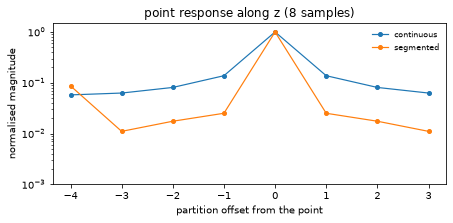

In [11]:
def z_profile(cube):
    '''The point object's own image along z, normalised to its peak.'''
    image = np.abs(np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(cube))))
    line = image[NX // 2, NY // 2, :]
    return line / line.max()


prof_cont, prof_seg = z_profile(k_cont_pt), z_profile(k_seg_pt)
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(np.arange(NZ) - NZ // 2, prof_cont, 'o-', lw=1.2, ms=4, label='continuous')
ax.plot(np.arange(NZ) - NZ // 2, prof_seg, 'o-', lw=1.2, ms=4, label='segmented')
ax.set(xlabel='partition offset from the point', ylabel='normalised magnitude',
       yscale='log', ylim=(1e-3, 1.5), title=f'point response along z ({NZ} samples)')
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

for name, p in (('continuous', prof_cont), ('segmented', prof_seg)):
    print(f'{name:12s} summed off-peak magnitude in this {NZ}-sample z profile: {p.sum() - 1:.3f}')

### Reading that honestly

The per-partition row is the primary evidence, and the `z` profile beside it is a visualisation of
the same thing -- **not** a resolution measurement. It is a summed normalised magnitude over eight
samples; it is not energy, and eight samples are far too coarse to quote a width or a sidelobe
ratio from. The number is reported as what it is.

What the two rows show is that the acquisitions modulate k-space in different *shapes*. The
continuous acquisition pays its transient once, and the loop order spreads that single decay along
`kz`, so the partition means slope. The segmented acquisition pays it once per segment, so the
slope is replaced by a shorter pattern that repeats at the segment period.

Which of those costs more depends on the protocol, and specifically on how a segment's length
compares with the transient. Here white matter decays with a time constant of about 83 repetitions
while a segment is 64 views, so no segment gets far down its own decay -- the regime where the
repeated pattern stays shallow. Longer segments would let each one settle and turn the boundaries
into steps instead. The measurement below is evidence about this protocol, not a general ranking.

peak |difference| 0.5911, 0.122 of the continuous peak
rms difference    0.04128


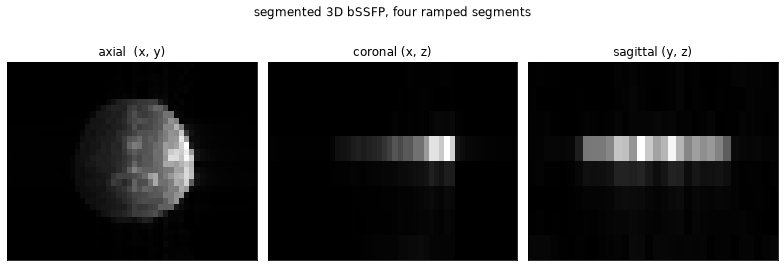

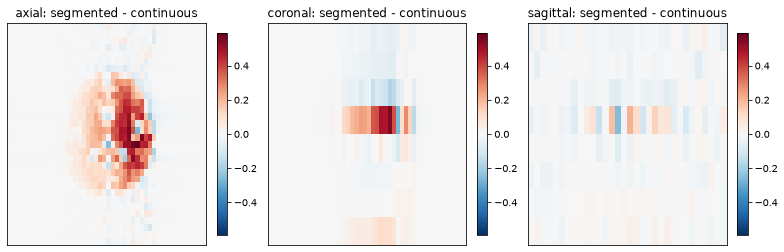

In [12]:
if BRAIN_IMAGES:
    rows_seg = simulate(SEQ_DIR / 'bssfp_3d_validation_segmented.seq', brain)
    k_seg, vol_seg = reconstruct(rows_seg)
    three_planes(np.abs(vol_seg), 'segmented 3D bSSFP, four ramped segments')

    a, b = np.abs(vol_cont), np.abs(vol_seg)
    diff = b - a
    scale = np.abs(diff).max()
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
    for ax, (name, plane) in zip(axes, (('axial', diff[:, :, NZ // 2].T),
                                        ('coronal', diff[:, NY // 2, :].T),
                                        ('sagittal', diff[NX // 2, :, :].T))):
        im = ax.imshow(plane, cmap='RdBu_r', origin='lower', aspect='auto',
                       vmin=-scale, vmax=scale)
        ax.set(title=f'{name}: segmented - continuous', xticks=[], yticks=[])
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    print(f'peak |difference| {scale:.4g}, {scale / a.max():.3f} of the continuous peak')
    print(f'rms difference    {np.sqrt((diff ** 2).mean()):.4g}')
else:
    print('BRAIN_IMAGES is off -- the point-object rows above are the quantitative result')

## 5. Does it behave like bSSFP?

Balanced gradients and a correct geometry would look the same for any 3D Cartesian acquisition. The
signature that says *balanced SSFP* is the off-resonance response: periodic in off-resonance with
period `1/TR`, and with nulls whose position depends on the RF phase increment. Under the `0/pi`
cycle used here they sit at `+-1/(2 TR)`, which is what puts the passband on resonance.

The sweep below uses the **ramped** diagnostic train -- the shipped preparation -- and reads its
tail. That tail is usable as a steady-state value because the train is 450 repetitions and white
matter reaches 1% in about 380; at the band edge the decay is faster still.

deepest two samples at -119 and +119 Hz; 1/(2 TR) predicts -119 and +119 Hz
worst tail spread over the last 40 repetitions of any sweep point: 0.0095 (so "settled" is a measured claim, not an assumption)
passband ripple within +-20 Hz: 1.00x


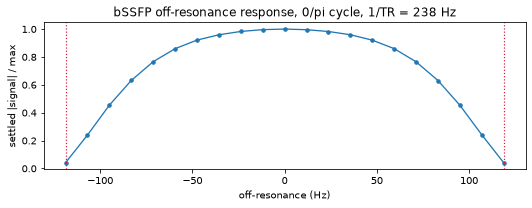

In [13]:
first_ramp, k_ramp = BUILT[f'{RAMP_STEPS}-step ramp']
sweep_hz = np.linspace(-NULL_HZ, NULL_HZ, 21)
response, converged = [], []
for df in sweep_hz:
    rows = simulate(DIAG_DIR / f'prep_ramp{RAMP_STEPS}.seq', voxel(B0=float(df),
                                                                  **TISSUES['white matter']))
    s = np.abs(rows[first_ramp:, ECHO])
    response.append(s[-40:].mean())
    #: the tail's own spread, as a check that calling it settled is honest
    converged.append(s[-40:].std() / s[-40:].mean())
response, converged = np.array(response), np.array(converged)

fig, ax = plt.subplots(figsize=(7.5, 3.0))
ax.plot(sweep_hz, response / response.max(), 'o-', lw=1.3, ms=3.5)
for null in (-NULL_HZ, NULL_HZ):
    ax.axvline(null, color='crimson', ls=':', lw=1.2)
ax.set(xlabel='off-resonance (Hz)', ylabel='settled |signal| / max',
       title=f'bSSFP off-resonance response, 0/pi cycle, 1/TR = {1 / TR_S:.0f} Hz')
fig.tight_layout()

deepest = sweep_hz[np.argsort(response)[:2]]
print(f'deepest two samples at {deepest[0]:+.0f} and {deepest[1]:+.0f} Hz; '
      f'1/(2 TR) predicts {-NULL_HZ:+.0f} and {NULL_HZ:+.0f} Hz')
print(f'worst tail spread over the last 40 repetitions of any sweep point: {converged.max():.4f} '
      f'(so "settled" is a measured claim, not an assumption)')
print(f'passband ripple within +-20 Hz: '
      f'{response[np.abs(sweep_hz) < 20].max() / response[np.abs(sweep_hz) < 20].min():.2f}x')

## 6. What remains a protocol choice

Everything measured above follows from decisions that live **above** the repetition. None of them
has been shown optimal here -- only what each one does on this protocol.

```text
preparation       a 24-step flip ramp.  It beats alpha/2 - TR/2 across the band and ties it on
                  resonance and under B1 error.  It does not change the decay rate; nothing can.

segment size      four segments.  Fewer, longer segments pay the transient fewer times but let
                  each segment settle, which changes the shape of the modulation, not just its
                  amount.

view order        loop order with a bidirectional ky sweep, so no repetition jumps across the
                  table.  A contrast-prepared protocol would additionally rotate each line's
                  start so the central views land at a chosen moment.

recovery          one second.  More recovery means more relaxation, so a larger transient at the
                  start of the next segment; the two are not independent.

phase increment   180 degrees, which places the passband on resonance.
```

**Limitations.** One phantom, one field strength, no B1 map, no motion, and a reduced matrix. The
off-resonance sweep is a single voxel, so it shows the response and not what banding does to an
image. The representative protocol is written but not simulated; what is simulated shares its
preparation, phase cycle, ordering, segmentation and TR, and differs in encoding.

## Summary

- The transient's **rate** is an eigenvalue of the repetition's transfer matrix, computed here
  rather than inferred from a finite run. A preparation changes the initial error, not the rate.
- Preparation was chosen by measuring across the off-resonance band, not only on resonance.
  `alpha/2 - TR/2` and a flip ramp tie at the passband centre and under `+-10%` B1; the ramp is
  better toward the band edge, which is why `01` ships it.
- CSF is excluded from settling claims: its eigenvalue implies roughly 2500 repetitions to 5%, so
  no tail available here is its steady state.
- Both acquisitions walk the table `01` recorded, and `01` asserts that contract itself in CI.
- The continuous acquisition reconstructs into the expected volume in all three planes.
- Segmentation changes the *shape* of the k-space modulation. Which shape costs more depends on
  how a segment compares with the transient, and that is stated as protocol-specific.
- The off-resonance response is periodic with nulls at `+-1/(2 TR)` under the `0/pi` cycle, with
  the tail's own spread reported so "settled" is measured rather than assumed.

## References

- Bieri O, Scheffler K. *Fundamentals of balanced steady state free precession MRI.*
  J Magn Reson Imaging 2013;38:2-11.
- Bernstein MA, King KF, Zhou XJ. *Handbook of MRI Pulse Sequences.* Elsevier, 2004, Section 14.1.
- Hargreaves BA, Vasanawala SS, Pauly JM, Nishimura DG. *Characterization and reduction of the
  transient response in steady-state MR imaging.* Magn Reson Med 2001;46:149-158.
- Le Roux P. *Simplified model and stabilization of SSFP sequences.* J Magn Reson 2003;163:23-37.
- Spincemaille P, Nguyen TD, Wang Y. *View ordering for magnetization prepared steady state free
  precession acquisition: application in contrast-enhanced MR angiography.*
  Magn Reson Med 2004;52:461-466.
- Scheffler K. *On the transient phase of balanced SSFP sequences.* Magn Reson Med 2003;49:781-783.